# SuperPoint


## 1. Concept and objective

In large ocean basins, a sea state may contain a locally generated wind sea and several swell systems produced by distant storms. These components travel with different frequencies and directions, so bulk parameters such as a single wave height, period and direction can hide the multimodal structure of the wave field. This is especially relevant in the Pacific and tropical regions, where several swell systems frequently coexist.

A **SuperPoint** is a virtual offshore point that combines directional spectra from several locations surrounding the area of interest. Each input point contributes the energy associated with a prescribed directional sector. The result represents the spectral energy that can approach the site from every direction, including energy shadowed by islands or atolls at an individual hindcast point.

> Cagigal et al. (2021) introduced the construction around Majuro and Arno using six hindcast points, one 60° sector per point, and hourly spectra. This notebook generalizes that construction: the number of points, file names, variable names, coordinates, sector widths and overlap are all configurable.

For direction $\theta$, the implementation can be summarized as

$$S_{SP}(t,f,\theta) = \frac{1}{N_{\theta}} \sum_i w_i(\theta) S_i(t,f,\theta),$$

where $S_i$ is the directional spectrum at point $i$, $w_i$ selects its assigned sector (including the optional overlap `deg_sup`), and $N_{\theta}$ is the number of contributing points. Averaging where sectors overlap avoids duplicating energy.

This example will:

1. configure ten spectra around Samoa and their directional sectors;
2. inspect the station geometry and possible land-shadowing;
3. construct the virtual SuperPoint;
4. compare input and aggregated spectra; and
5. calculate bulk parameters and sea/swell partitions with `wavespectra`.

## 2. Imports


In [1]:
# common
import os
import os.path as op

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# pip
import xarray as xr
import numpy as np

from utils.superpoint import (
    spectra_superposition, validate_directional_sectors,
    bulkparams_partitions, plot_points,
    plot_input_spectra, Plot_spectrum,
    Plot_seasons_spectra, Plot_bulk_parameters, Plot_partitions,
)


## 3. Configure data, sectors and output

The bundled example contains one year of spectra sampled every three hours. Input point names are independent of NetCDF file names, and all dataset conventions are declared explicitly below.

In [2]:
# Input and output paths.
p_input = op.abspath(op.join('utils', 'data', 'example_superpoint'))
p_output = op.abspath(op.join('..', '..', 'data', 'waves', 'superpoint'))
p_spec = p_output

# Each key is a user-defined point name; NetCDF file names are arbitrary.
spectra_paths = {
    '2193': op.join(p_input, 'station_2193.nc'),
    '2195': op.join(p_input, 'station_2195.nc'),
    '2188': op.join(p_input, 'station_2188.nc'),
    '2179': op.join(p_input, 'station_2179.nc'),
    '2170': op.join(p_input, 'station_2170.nc'),
    '2168': op.join(p_input, 'station_2168.nc'),
    '2166': op.join(p_input, 'station_2166.nc'),
    '2175': op.join(p_input, 'station_2175.nc'),
    '2183': op.join(p_input, 'station_2183.nc'),
    '2191': op.join(p_input, 'station_2191.nc'),
}

# Use only one year for this example. The selection remains lazy until data
# are needed, so the complete files are not loaded into memory here.
test_period = slice('1979-01-01', '1979-12-31T23:59:59')
spectra = {
    name: xr.open_dataset(path).sel(time=test_period)
    for name, path in spectra_paths.items()
}
point_coordinates = {
    '2193': (-172.07, -12.93),  # (longitude, latitude)
    '2195': (-171.00, -12.93),
    '2188': (-170.47, -13.47),
    '2179': (-170.47, -14.00),
    '2170': (-171.00, -14.53),
    '2168': (-172.07, -14.53),
    '2166': (-173.13, -14.53),
    '2175': (-173.13, -14.00),
    '2183': (-173.13, -13.47),
    '2191': (-173.13, -12.93),
}
# Used only for map placement; it does not enter the spectral calculation.
site_coordinates = (-172.07, -13.76)
point_sectors = {
    '2193': (337.5, 22.5),
    '2195': (22.5, 60),
    '2188': (60, 90),
    '2179': (90, 120),
    '2170': (120, 157.5),
    '2168': (157.5, 202.5),
    '2166': (202.5, 240),
    '2175': (240, 270),
    '2183': (270, 300),
    '2191': (300, 337.5),
}
validate_directional_sectors(point_sectors)
point_order = list(spectra)
wind_point = '2195'
deg_sup = 15

# Input dataset names. Change these without modifying the utilities.
variable_names = dict(
    time_n='time', freq_n='frequency', dir_n='direction', efth_n='efth',
    wspeed_n='u10m', wdir_n='udir', depth_n='depth',
)

# wavespectra partition parameters.
part0 = True           # Keep the wind-sea partition.
wcut = 0.00000000001   # Wind-sea cutoff.
msw = 8                # Maximum number of swell partitions.
agef = 1.7             # Wave-age factor.


# output files
p_superpoint = op.join(p_spec, 'super_point_superposition_.nc')
p_chunks = op.join(p_spec, 'chunks')
p_partitions = op.join(p_spec, 'partitions_stats.nc')
p_bulk = op.join(p_spec, 'bulk_params.nc')


# Create the output directory if needed.
os.makedirs(p_spec, exist_ok=True)


## 4. Inspect the input-point geometry


Each station supplies one directional sector. Together, the sectors cover the full directional circle; the cyan wedges show which part of each spectrum is retained. The gold star is the virtual SuperPoint location used only for visualization.


### 4.1 Station map and directional coverage


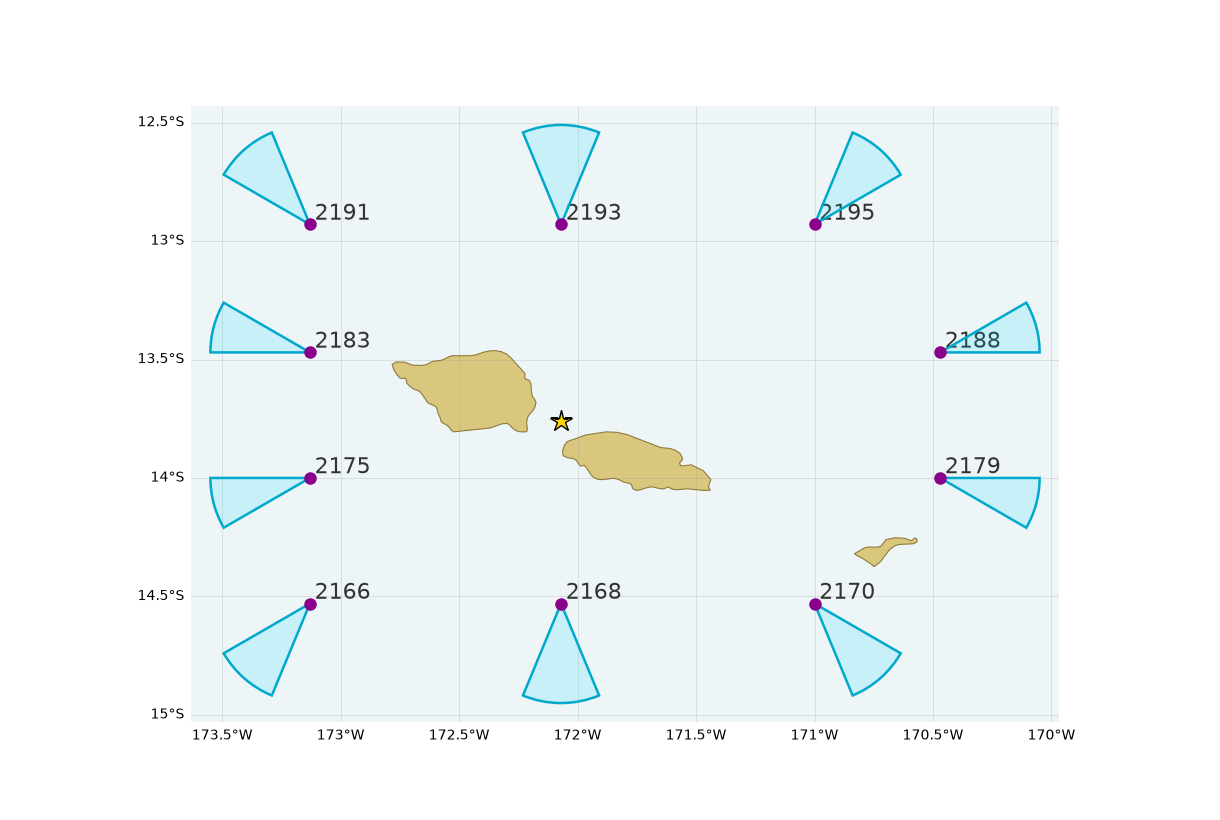

In [3]:
# plot Super Point stations
fig = plot_points(
    point_coordinates, site_coordinates,
    point_sectors=point_sectors,
    sector_radius=0.42,
    extra_area=0.5,
    figsize = [12, 8],
)

## 5. Construct the SuperPoint

`spectra_superposition` converts the input direction convention when requested, extracts the sector assigned to each point, averages overlapping directions and returns a spectrum with `time`, `freq` and `dir` dimensions. Wind and depth are copied from `wind_point` because they are required later for sea/swell partitioning.

In [4]:
# Super Point spectra superposition
super_point = spectra_superposition(
    spectra, point_sectors, deg_sup, wind_point, **variable_names
)
super_point.to_netcdf(p_superpoint)  

#super_point = xr.open_dataset(p_superpoint)

# remove wind so no sea partition is created
if not part0:
    super_point.Wspeed.values = np.zeros(np.shape(super_point.Wspeed.values))


Point: 2193
Point: 2195
Point: 2188
Point: 2179
Point: 2170
Point: 2168
Point: 2166
Point: 2175
Point: 2183
Point: 2191


## 6. Inspect an instantaneous sea state

The map below places every input spectrum at its station, outlines the sector used by the SuperPoint and displays the aggregated spectrum at the gold star. Differences among stations illustrate the land-shadowing problem: no single point necessarily observes all energy approaching the island group.

The shared color scale represents $\sqrt{S}$ and makes the input and aggregated spectra directly comparable.

The selected sectors are a property of the application, not of the files. For a new site they should be chosen from station geometry, coastline exposure and the direction convention of the source dataset.

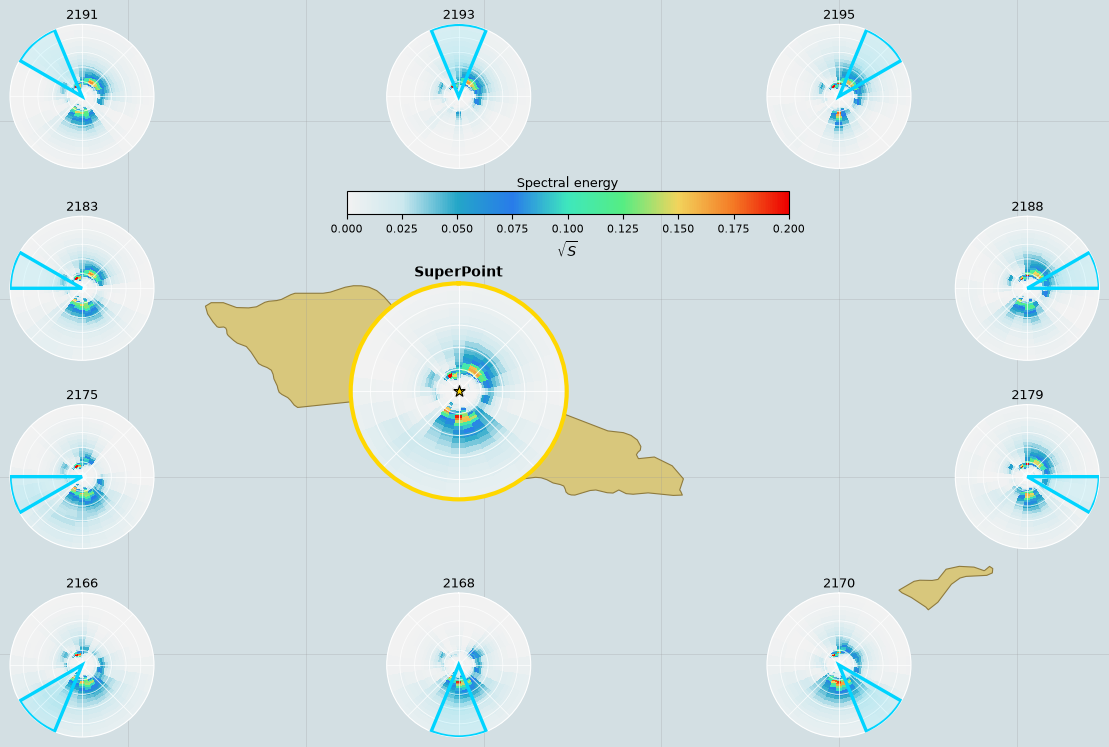

In [5]:

time_index = 70  # time to plot the spectra (0-2919)

plot_input_spectra(
    spectra, point_order, time_index,
    point_coordinates=point_coordinates,
    point_sectors=point_sectors,
    site_coordinates=site_coordinates,
    super_point=super_point,
    figsize=[20, 12],
    map_padding=0.5,
    spectrum_size=0.12,
    superpoint_size=0.18,
    **{key: variable_names[key] for key in ('time_n', 'freq_n', 'dir_n', 'efth_n')},
);


### 6.1 Aggregated spectrum

The same SuperPoint spectrum is shown separately for closer inspection.

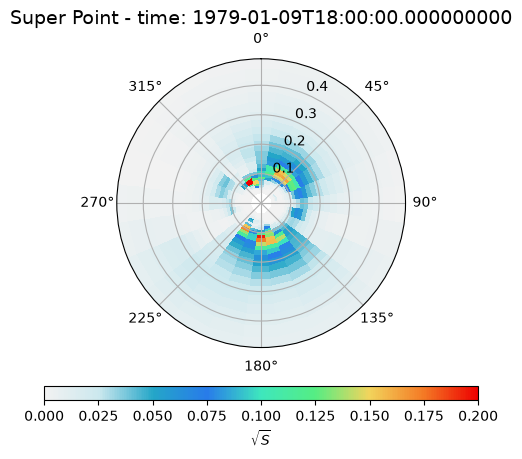

In [6]:
Plot_spectrum(super_point, time_index, figsize=[8, 5]);


## 7. Time-averaged diagnostics

The temporal mean summarizes the directional-frequency climate represented by this lightweight 1979 example. It should not be interpreted as the full 1979–2019 climatology analyzed in the publication.

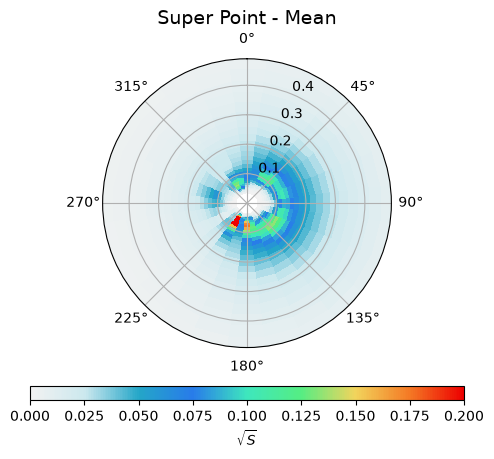

In [7]:
Plot_spectrum(super_point, average=True, figsize=[8, 5]);


### 7.1 Seasonal spectra

Seasonal means expose changes in the dominant swell and wind-sea directions during DJF, MAM, JJA and SON.

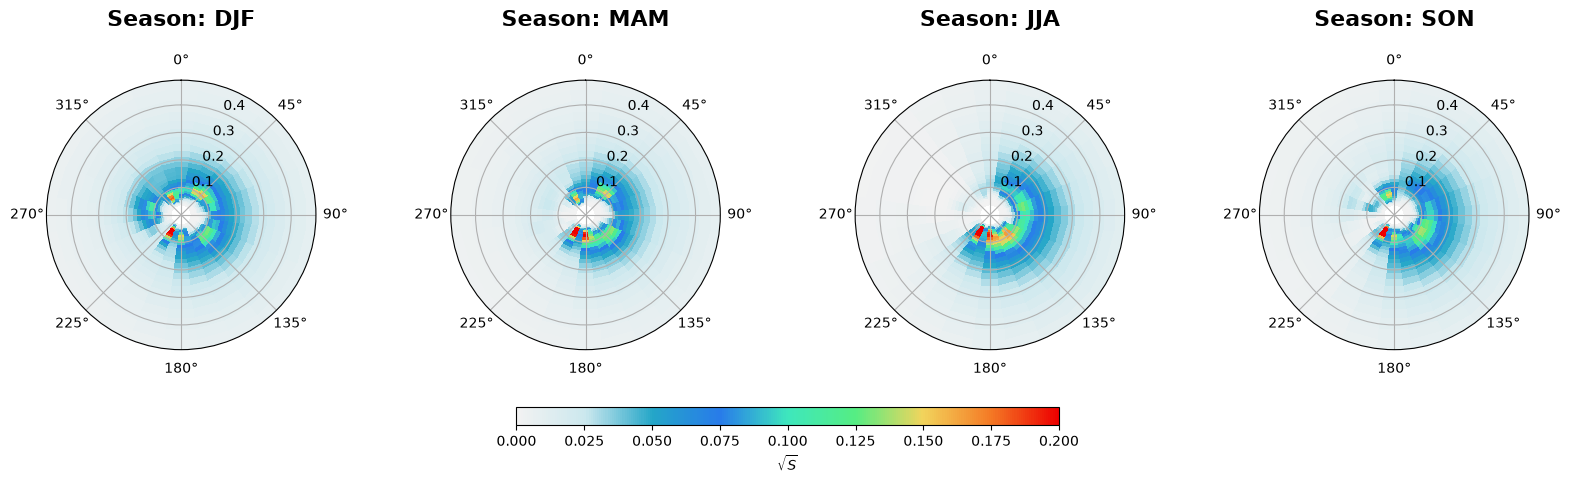

In [8]:
Plot_seasons_spectra(super_point);


## 8. Partition the spectrum and calculate bulk parameters


`wavespectra` applies the PTM1 watershed partitioning method to separate the wind sea from concurrent swell systems. The resulting partitions are summarized with significant wave height (`hs`), peak period (`tp`), mean zero-crossing period (`tm02`), peak direction (`dpm`) and directional spread (`dspr`).

> The SuperPoint construction and spectral partitioning are separate operations. A SuperPoint can be used directly as a directional spectrum; partitioning is included here to demonstrate the sea/swell decomposition used downstream in Cagigal et al. (2021).

In [9]:
# obtain superpoint partitons and bulk parameters
bulk_params, stats_part = bulkparams_partitions(
    p_chunks, super_point, chunks=3, 
    wcut=wcut, msw=msw, agef=agef,
)

# store partitions and bulk parameters
bulk_params.to_netcdf(p_bulk)
stats_part.to_netcdf(p_partitions)

#bulk_params = xr.open_dataset(p_bulk)
#stats_part = xr.open_dataset(p_partitions)


chunk 1/3 done.
chunk 2/3 done.
chunk 3/3 done.


### 8.1 SuperPoint bulk parameters


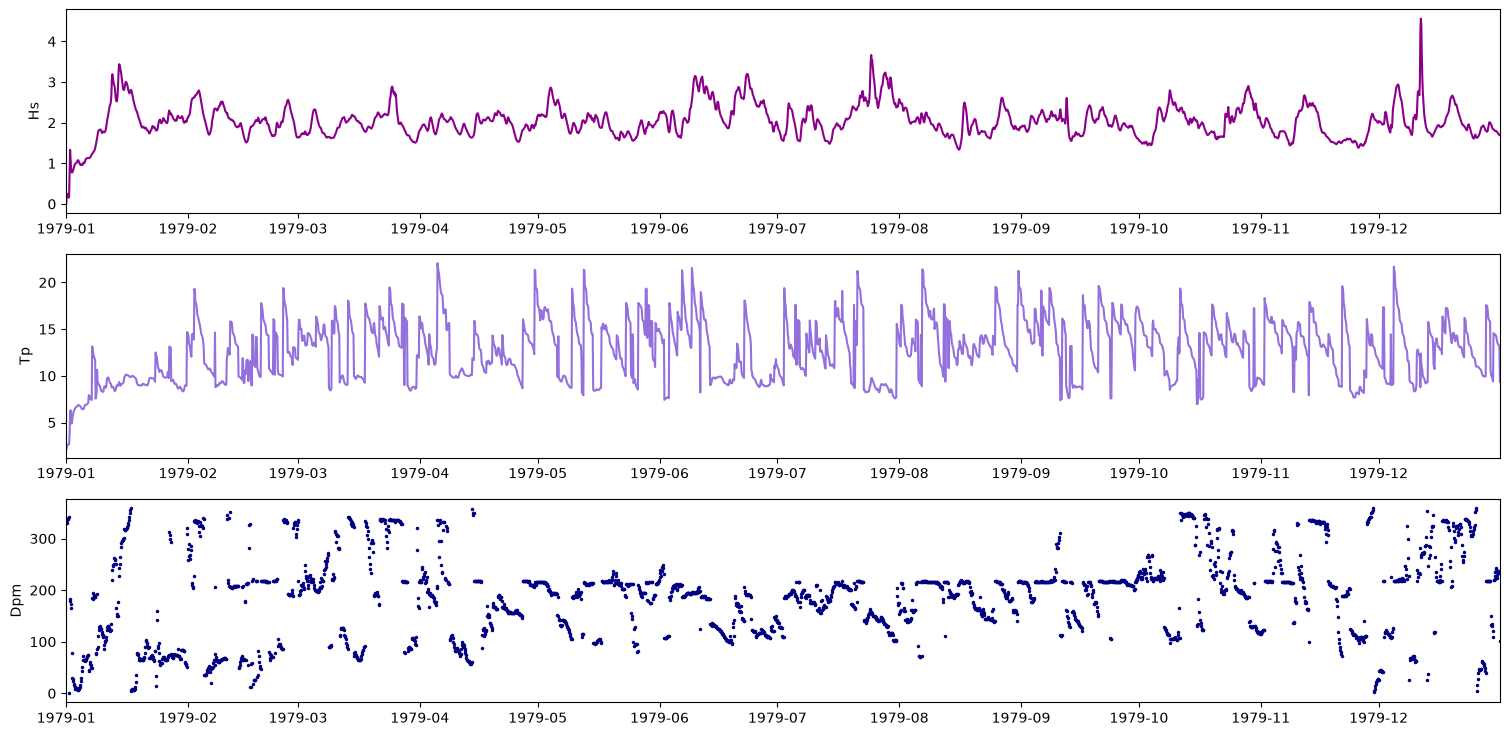

In [10]:
Plot_bulk_parameters(bulk_params);

### 8.2 Sea and swell partitions


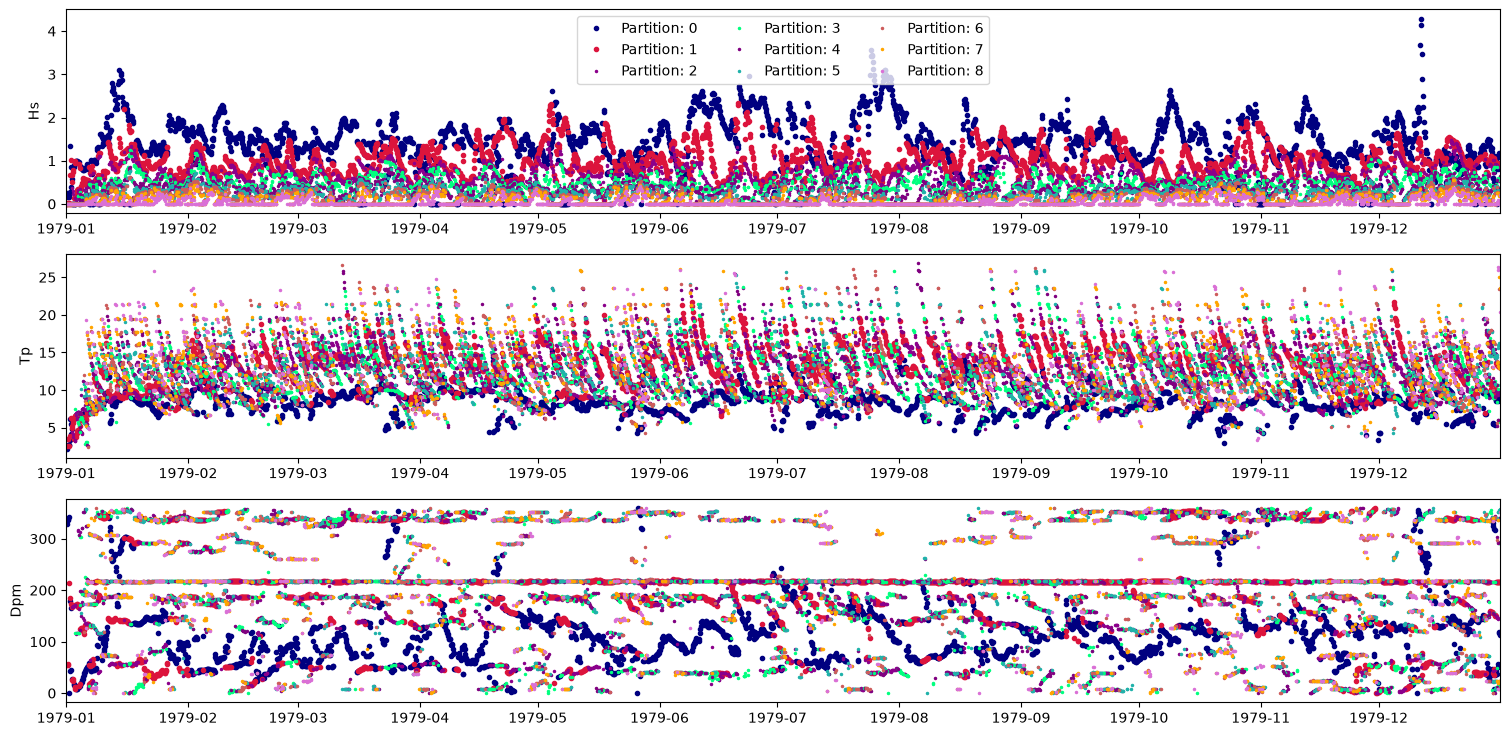

In [11]:
Plot_partitions(stats_part, num_fig=1);

## 9. Summary

The SuperPoint is a sector-wise aggregation of surrounding directional spectra, designed to represent all wave energy capable of approaching a site despite local land shadowing. It preserves multimodal information that would be lost in a single set of bulk parameters. Reliable application requires synchronized input spectra, compatible frequency and direction coordinates, complete directional coverage and sectors that are physically consistent with the station geometry.

This notebook intentionally uses a short three-hourly subset for reproducibility. For climate analysis, replace `spectra_paths` with the full-resolution records and review the sector definitions for the study area.

## Reference

Cagigal, L., Rueda, A., Ricondo, A., Pérez, J., Ripoll, N., Coco, G., & Méndez, F. J. (2021). *Climate-based emulator of distant swell trains and local seas approaching a Pacific atoll*. Journal of Geophysical Research: Oceans, 126, e2020JC016919. [https://doi.org/10.1029/2020JC016919](https://doi.org/10.1029/2020JC016919)

The SuperPoint definition summarized here is based on Section 3.1 of that article.